# ALS Hyperparameter Tuning

Grid search over ALS parameters using temporal train/val split.

## 1. Setup

### 1.1. Imports

In [1]:
import sys
sys.path.insert(0, '..')

import json
import pickle
import time
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm

from src.data.loader import load_ratings
from src.data.splitter import split_temporal
from src.data.adapter import DataAdapter
from src.models.als import ALS
from src.evaluation.metrics import compute_rmse, compute_ranking_metrics

### 1.2 Load and split data

In [2]:
ratings = load_ratings()

train_df, val_df, test_df = split_temporal(
    ratings, 
    train_ratio=0.7, 
    validation_ratio=0.15, 
    test_ratio=0.15,
)

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

# Convert to IMPLICIT feedback for ALS (rating >= 4 = positive interaction)
adapter = DataAdapter()
train_data = adapter.to_implicit(train_df, threshold=4.0)

print(f"Positive interactions in training: {train_data.X_ui.nnz:,}")

Train: 700,118 | Val: 150,081 | Test: 150,010
Positive interactions in training: 416,338


## 2. Tuning

### 2.1 Grid search parameters


In [3]:
param_grid = {
    'factors': [10, 20, 30, 40, 50, 100],
    'regularization': [0.001, 0.01, 0.1],
    'iterations': [10, 15, 30],
}

# Generate all combinations
param_names = list(param_grid.keys())
param_values = list(param_grid.values())
all_combinations = list(product(*param_values))

print(f"Total combinations to try: {len(all_combinations)}")

Total combinations to try: 54


### 2.2 Grid search

In [4]:
results = []

# Only evaluate against positive validation interactions
val_positive = val_df[val_df['rating'] >= 4]
val_users = val_positive['user_id'].unique()

for combo in tqdm(all_combinations, desc="Grid Search"):
    params = dict(zip(param_names, combo))
    
    model = ALS(**params, random_state=42)
    
    start_time = time.time()
    model.fit(train_data)
    train_time = time.time() - start_time
    
    # Generate recommendations for ranking eval
    recommendations = model.recommend_for_eval(val_users, k=10)
    val_ranking = compute_ranking_metrics(val_positive, recommendations, top_k=10)
    
    result = {
        **params,
        'val_ndcg': val_ranking['ndcg'],
        'val_recall': val_ranking['recall'],
        'train_time_sec': train_time,
    }
    results.append(result)
    
    print(f"{params} -> NDCG: {val_ranking['ndcg']:.4f} ({train_time:.1f}s)")

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('val_ndcg', ascending=False)
results_df.head(10)

,factors,regularization,iterations,val_ndcg,val_recall,train_time_sec
8,10,0.100,30,0.086180,0.072492,0.690924
48,100,0.010,10,0.085907,0.084168,0.698809
7,10,0.100,15,0.085755,0.073019,0.460722
47,100,0.001,30,0.085314,0.082743,1.751168
50,100,0.010,30,0.085017,0.081452,1.921510
6,10,0.100,10,0.084942,0.071858,0.389313
45,100,0.001,10,0.084932,0.082942,0.737866
49,100,0.010,15,0.084869,0.081977,0.973813
46,100,0.001,15,0.084705,0.082195,0.955533
5,10,0.010,30,0.084648,0.071970,0.680070


In [5]:
# Best parameters (by NDCG)
best_row = results_df.iloc[0]
best_params = {
    'factors': int(best_row['factors']),
    'regularization': float(best_row['regularization']),
    'iterations': int(best_row['iterations']),
}

print("Best parameters:")
print(json.dumps(best_params, indent=2))
print(f"\nValidation NDCG@10: {best_row['val_ndcg']:.4f}")
print(f"Validation Recall@10: {best_row['val_recall']:.4f}")

Best parameters:
{
  "factors": 10,
  "regularization": 0.1,
  "iterations": 30
}

Validation NDCG@10: 0.0862
Validation Recall@10: 0.0725


## 3. Retrain best model

### 3.1 Retrain best model on train+val, evaluate on test

In [6]:
# Combine train and validation for final model
train_val_df = pd.concat([train_df, val_df], ignore_index=True)
train_val_data = adapter.to_implicit(train_val_df, threshold=4.0)

# Train final model
final_model = ALS(**best_params, random_state=42)
final_model.fit(train_val_data)

# Ranking eval (NDCG, etc.) - only on positive test interactions
test_positive = test_df[test_df['rating'] >= 4]
test_users = test_positive['user_id'].unique()
recommendations = final_model.recommend_for_eval(test_users, k=10)
ranking_metrics = compute_ranking_metrics(test_positive, recommendations, top_k=10)

print(f"Test NDCG@10: {ranking_metrics['ndcg']:.4f}")
print(f"Test MAP@10: {ranking_metrics['map']:.4f}")
print(f"Test Precision@10: {ranking_metrics['precision']:.4f}")
print(f"Test Recall@10: {ranking_metrics['recall']:.4f}")

Test NDCG@10: 0.0844
Test MAP@10: 0.0398
Test Precision@10: 0.0665
Test Recall@10: 0.0701


### 3.2 Save best model and results

In [7]:
artifacts_dir = Path('../artifacts')
artifacts_dir.mkdir(exist_ok=True)

# Save model
with open(artifacts_dir / 'als_best.pkl', 'wb') as f:
    pickle.dump(final_model, f)
print(f"Model saved to {artifacts_dir / 'als_best.pkl'}")

# Save parameters
params_to_save = {
    'best_params': best_params,
    'val_ndcg': float(best_row['val_ndcg']),
    'test_ranking_metrics': ranking_metrics,
}
with open(artifacts_dir / 'als_params.json', 'w') as f:
    json.dump(params_to_save, f, indent=2)
print(f"Parameters saved to {artifacts_dir / 'als_params.json'}")

# Save full results
results_df.to_csv(artifacts_dir / 'als_grid_search.csv', index=False)
print(f"Grid search results saved to {artifacts_dir / 'als_grid_search.csv'}")

Model saved to ../artifacts/als_best.pkl
Parameters saved to ../artifacts/als_params.json
Grid search results saved to ../artifacts/als_grid_search.csv


### 3.3  Visualize results

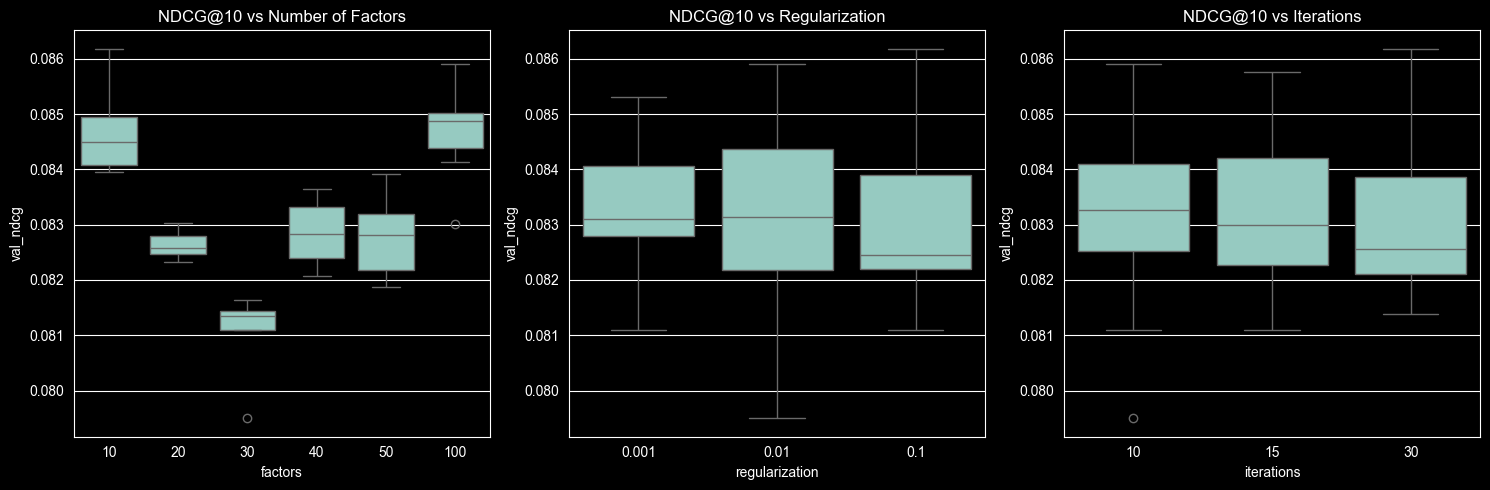

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# NDCG vs factors
ax = axes[0]
sns.boxplot(data=results_df, x='factors', y='val_ndcg', ax=ax)
ax.set_title('NDCG@10 vs Number of Factors')

# NDCG vs regularization
ax = axes[1]
sns.boxplot(data=results_df, x='regularization', y='val_ndcg', ax=ax)
ax.set_title('NDCG@10 vs Regularization')

# NDCG vs iterations
ax = axes[2]
sns.boxplot(data=results_df, x='iterations', y='val_ndcg', ax=ax)
ax.set_title('NDCG@10 vs Iterations')

plt.tight_layout()
plt.savefig(artifacts_dir / 'als_tuning_plots.png', dpi=150)
plt.show()